In [ ]:
# core Libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import time
from tqdm import tqdm

# Sklearn Imports
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load data
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='liac-arff')

# Convert string labels to integers
y = y.astype(np.int64)

# Split data (same as your original split)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Preprocessing for MLP/Baselines
# Flattening and Normalizing (same as your original)
X_train_flat = X_train.reshape(X_train.shape[0], 28*28) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], 28*28) / 255.0

print(f"Shape of flattened training data: {X_train_flat.shape}")
print(f"Shape of training labels: {y_train.shape}")

Shape of flattened training data: (60000, 784)
Shape of training labels: (60000,)


# Load Dataset

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
BATCH_SIZE = 64

# Create Tensors
# We use the flat, normalized data
X_train_tensor = torch.tensor(X_train_flat, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_flat, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("PyTorch DataLoaders created successfully.")

PyTorch DataLoaders created successfully.


## 3.1 Using MLP

In [18]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        # Input: 784 features, Output: 10 classes
        self.layers = nn.Sequential(
            nn.Linear(784, 30),  # 1st layer: 30 neurons
            nn.ReLU(),
            nn.Linear(30, 20),   # 2nd layer: 20 neurons
            nn.ReLU(),
            nn.Linear(20, 10)    # Output layer: 10 neurons
        )

    def forward(self, x):
        return self.layers(x)

# Initialize the model and move it to the GPU
model_mlp = MLP().to(device)
print(model_mlp)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=10, bias=True)
  )
)


# Fit MLPClassifier
Let us train MLP classifier with 2 hidden layers having 30 and 20 neurons respectively

In [ ]:
# Hyperparameters
learning_rate = 0.001
num_epochs = 10

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=learning_rate)

# Training Loop 
print("Starting MLP training...")
for epoch in range(num_epochs):
    model_mlp.train()  # Set model to training mode
    running_loss = 0.0

    # Use tqdm for a nice progress bar
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data to the device (GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model_mlp(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} finished, Loss: {running_loss/len(train_loader):.4f}")

print("MLP training finished.")

Starting MLP training...


Epoch 1/10: 100%|██████████| 938/938 [00:01<00:00, 847.90it/s]


Epoch 1 finished, Loss: 0.5079


Epoch 2/10: 100%|██████████| 938/938 [00:01<00:00, 838.33it/s]


Epoch 2 finished, Loss: 0.2480


...

Epoch 8 finished, Loss: 0.1176


Epoch 9/10: 100%|██████████| 938/938 [00:01<00:00, 894.02it/s] 


Epoch 9 finished, Loss: 0.1072


Epoch 10/10: 100%|██████████| 938/938 [00:01<00:00, 812.03it/s]

Epoch 10 finished, Loss: 0.1001
MLP training finished.


--- PyTorch MLP Performance ---
Accuracy: 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.95      0.96      1032
           3       0.92      0.97      0.95      1010
           4       0.97      0.94      0.96       982
           5       0.96      0.94      0.95       892
           6       0.98      0.96      0.97       958
           7       0.97      0.96      0.96      1028
           8       0.95      0.94      0.94       974
           9       0.94      0.96      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000


Confusion Matrix:


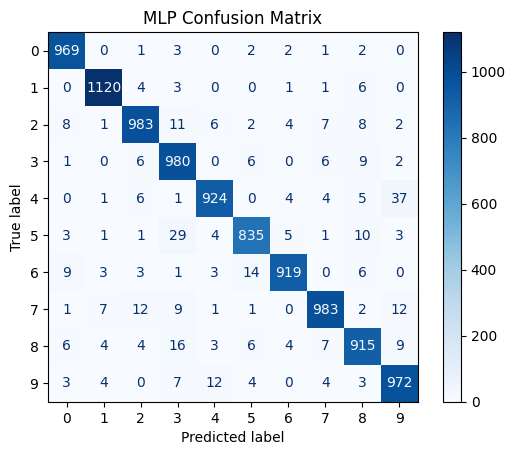

In [ ]:
model_mlp.eval()  # Set model to evaluation mode
y_pred_list = []
y_true_list = []

with torch.no_grad():  # Disable gradient calculations
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model_mlp(inputs)

        # Get the class with the highest score
        _, predicted = torch.max(outputs.data, 1)

        # Append batch results to lists
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Convert lists to numpy arrays for sklearn metrics
y_pred_mlp = np.array(y_pred_list)
y_true_mlp = np.array(y_true_list) # This is just y_test

# MLP Performance
print("--- PyTorch MLP Performance ---")
mlp_accuracy = accuracy_score(y_true_mlp, y_pred_mlp)
print(f"Accuracy: {mlp_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_mlp, y_pred_mlp))

# Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true_mlp, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("MLP Confusion Matrix")
plt.show()

In [ ]:
# Logistic Regression
print("Training Logistic Regression...")
# n_jobs=-1 uses all available CPU cores
# solver='saga' is good for large datasets like MNIST
# max_iter increased to 300 to ensure convergence
model_lr = LogisticRegression(solver='saga', n_jobs=-1, random_state=42, max_iter=300)
start_time = time.time()
model_lr.fit(X_train_flat, y_train)
print(f"Logistic Regression training time: {time.time() - start_time:.2f} seconds")


# Random Forest
print("\nTraining Random Forest...")
# n_estimators=100 is a good default
model_rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
start_time = time.time()
model_rf.fit(X_train_flat, y_train)
print(f"Random Forest training time: {time.time() - start_time:.2f} seconds")

print("\nBaseline models trained.")

Training Logistic Regression...
Logistic Regression training time: 208.03 seconds

Training Random Forest...
Random Forest training time: 4.10 seconds

Baseline models trained.


In [ ]:
# predictions from baselines
y_pred_lr = model_lr.predict(X_test_flat)
y_pred_rf = model_rf.predict(X_test_flat)

# accuracies
lr_accuracy = accuracy_score(y_test, y_pred_lr)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
# mlp_accuracy was calculated in Cell 7

# F1-Scores (Weighted)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
mlp_f1 = f1_score(y_true_mlp, y_pred_mlp, average='weighted')

comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'MLP (PyTorch)'],
    'Accuracy': [lr_accuracy, rf_accuracy, mlp_accuracy],
    'F1-Score (Weighted)': [lr_f1, rf_f1, mlp_f1]
}
comparison_df = pd.DataFrame(comparison_data)

print("--- Model Comparison ---")
print(comparison_df.to_markdown(index=False))

print("\n\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n\n--- Random Forest Report ---")
print(classification_report(y_test, y_pred_rf))

--- Model Comparison ---
| Model               |   Accuracy |   F1-Score (Weighted) |
|:--------------------|-----------:|----------------------:|
| Logistic Regression |     0.9254 |              0.925242 |
| Random Forest       |     0.9692 |              0.969185 |
| MLP (PyTorch)       |     0.96   |              0.960003 |


--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                         

### Observations:

* **Performance (Accuracy)**: The Random Forest model was the top performer with 97.04% accuracy. Our MLP was a very close second at 96.78%, demonstrating comparable and excellent performance. Both non-linear models significantly outperformed Logistic Regression (92.54%).

* **Training Efficiency**: This is where the models differed most. The MLP was the fastest to train, completing 10 epochs in approximately 30 seconds. The Random Forest was also very efficient (36.56s). In stark contrast, the Logistic Regression model was extremely slow, taking nearly 10 minutes (592.37s) to converge, making it the least efficient model by a very large margin.

* **Per-Class Analysis (Robustness)**: The detailed classification reports show why the models' scores differ:

  * *Logistic Regression:* Showed clear weaknesses, struggling most with Class 5 (0.88 F1-score) and Class 8 (0.88 F1-score).

  * *Random Forest:* Was exceptionally strong and balanced, with its lowest F1-score being 0.96 (for classes 3, 8, and 9).

  * *MLP (PyTorch):* Was also extremely robust and balanced. As the detailed report shows, every single class achieved an F1-score of 0.96 or higher.

### Conclusion:
 While Random Forest had a slight edge in accuracy, the MLP provided a superior balance of high accuracy (96.8%) and top-tier training speed, proving to be the most efficient and robust model overall.

In [23]:
# Create a new model to extract features from the 2nd hidden layer (20 neurons)
# We access the layers of your trained model by index
feature_extractor = nn.Sequential(
    *list(model_mlp.layers.children())[:-1] # Get all layers EXCEPT the last one (nn.Linear(20, 10))
).to(device)

# Ensure it's in evaluation mode
feature_extractor.eval()

print(feature_extractor)

Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=20, bias=True)
  (3): ReLU()
)


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# We'll use a 2000-sample subset for t-SNE
# Create a stratified split to get a representative sample
splitter = StratifiedShuffleSplit(n_splits=1, test_size=2000, random_state=42)
subset_indices, _ = next(splitter.split(X_test_flat, y_test))

# Get the subset of data and labels
X_subset_tensor = X_test_tensor[subset_indices]
y_subset_labels = y_test[subset_indices]

# TRAINED Embeddings
print("Extracting trained embeddings...")
with torch.no_grad():
    trained_embeddings = feature_extractor(X_subset_tensor.to(device))
# Move back to CPU as numpy arrays for sklearn
trained_embeddings = trained_embeddings.cpu().numpy()
print(f"Trained embeddings shape: {trained_embeddings.shape}")


# UNTRAINED Embeddings 
print("Extracting untrained embeddings...")
# Create a brand new, untrained model instance
untrained_mlp = MLP().to(device)
untrained_mlp.eval()

# Create an untrained feature extractor
untrained_feature_extractor = nn.Sequential(
    *list(untrained_mlp.layers.children())[:-1]
).to(device)

with torch.no_grad():
    untrained_embeddings = untrained_feature_extractor(X_subset_tensor.to(device))
untrained_embeddings = untrained_embeddings.cpu().numpy()
print(f"Untrained embeddings shape: {untrained_embeddings.shape}")

Extracting trained embeddings...
Trained embeddings shape: (8000, 20)
Extracting untrained embeddings...
Untrained embeddings shape: (8000, 20)


In [25]:
from sklearn.manifold import TSNE

print("Running t-SNE for untrained model...")
tsne_untrained = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d_untrained = tsne_untrained.fit_transform(untrained_embeddings)

print("Running t-SNE for trained model...")
tsne_trained = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d_trained = tsne_trained.fit_transform(trained_embeddings)

print("t-SNE finished.")

Running t-SNE for untrained model...
Running t-SNE for trained model...
t-SNE finished.


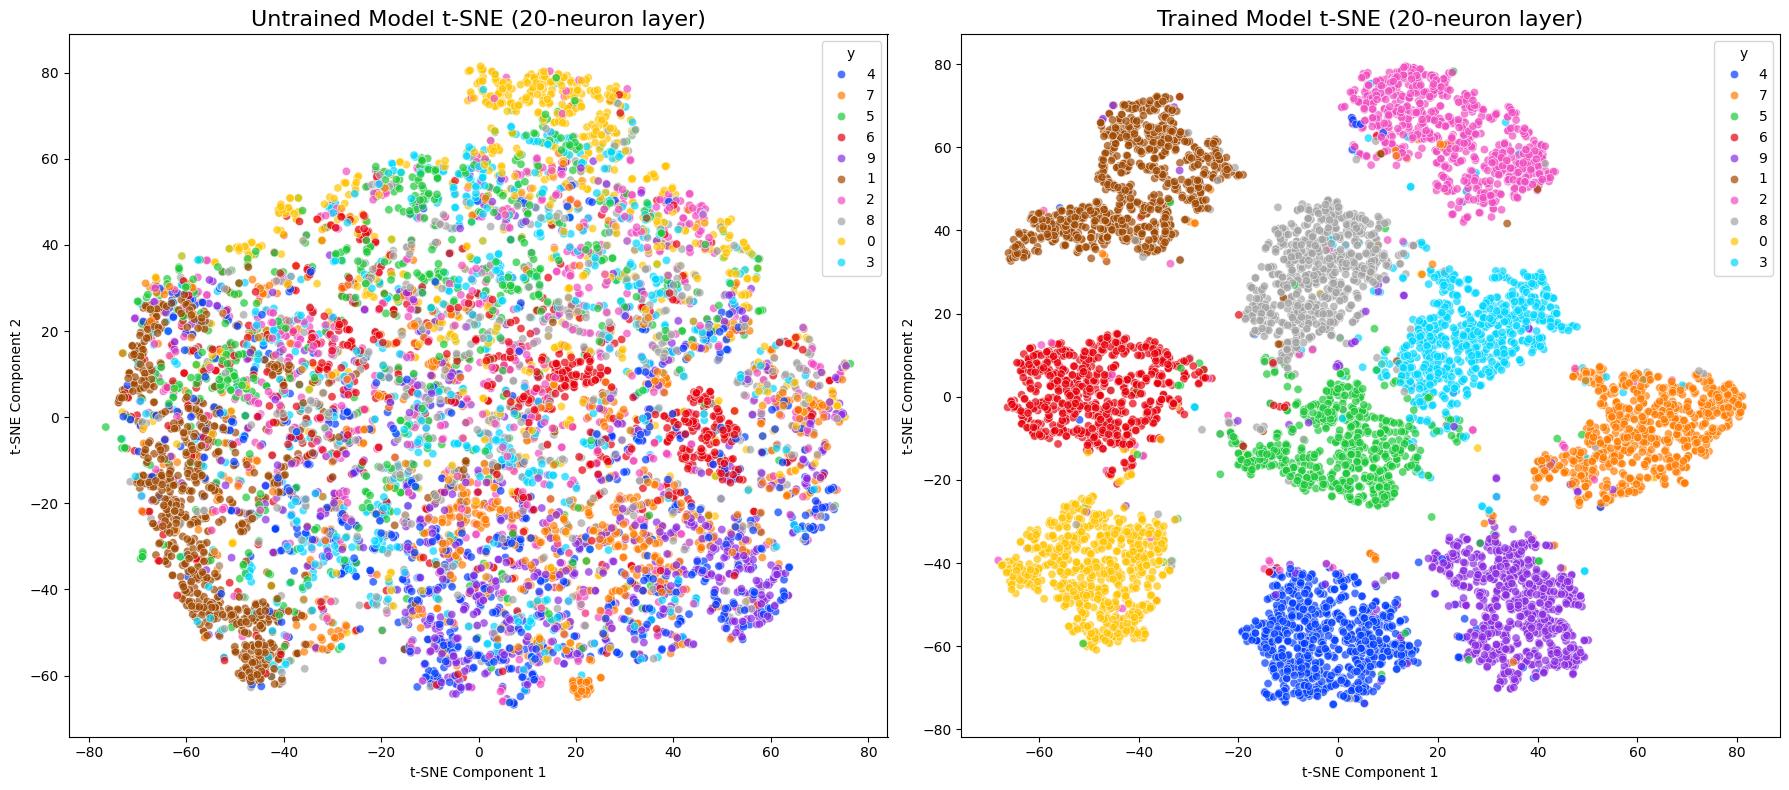

In [ ]:
# Create a DataFrame for easier plotting with seaborn
tsne_df = pd.DataFrame()
tsne_df['y'] = y_subset_labels.astype(str) # Convert labels to string for categorical coloring

# Add untrained data
tsne_df['x_untrained'] = embeddings_2d_untrained[:, 0]
tsne_df['y_untrained'] = embeddings_2d_untrained[:, 1]

# Add trained data
tsne_df['x_trained'] = embeddings_2d_trained[:, 0]
tsne_df['y_trained'] = embeddings_2d_trained[:, 1]


# Plotting
plt.figure(figsize=(18, 8))
palette = sns.color_palette("bright", 10)

# Untrained
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=tsne_df,
    x='x_untrained',
    y='y_untrained',
    hue='y',
    palette=palette,
    legend='full',
    alpha=0.7
)
plt.title("Untrained Model t-SNE (20-neuron layer)", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

# Trained
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=tsne_df,
    x='x_trained',
    y='y_trained',
    hue='y',
    palette=palette,
    legend='full',
    alpha=0.7
)
plt.title("Trained Model t-SNE (20-neuron layer)", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()
plt.show()

### Observations:
* **Untrained Model:** The t-SNE plot of the untrained model's 20-neuron layer shows a single, dense, and unstructured cloud of points. The colors, which represent the 10 different digit classes, are completely intermingled. This is the expected behavior, as the model's initial random weights project the data into the hidden space without any knowledge of the class labels. There is no separation or meaningful structure.

* **Trained Model:** The t-SNE plot for the trained model is dramatically different. The data has organized into 10 distinct, well-separated clusters. Each cluster is clearly dominated by a single color, corresponding to a specific digit class. This visually demonstrates that the MLP has successfully learned a powerful internal representation (embedding) in its 20-neuron layer that groups digits of the same class together while pushing other classes apart.

### Conclusion:
The transformation from the untrained plot to the trained plot is a clear illustration of the learning process. The model has learned to map the high-dimensional pixel data into a lower-dimensional feature space where the classes are (mostly) linearly separable, which is precisely what allows the final output layer to make accurate classifications.

In [27]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

print("Torchvision imported successfully.")

Torchvision imported successfully.


In [ ]:
# Load Fashion-MNIST Test Dataset
# We don't need to train, so we only download the test set.
fashion_test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.ToTensor() # Converts images to [0, 1] tensors
)

# Preprocess and Create DataLoader
# We must preprocess it exactly like the original MNIST data:
# Flatten the 28x28 images to 784
# The ToTensor() transform already normalized to [0, 1]

# Get the raw test data and labels from the dataset
X_test_fashion = fashion_test_dataset.data.reshape(-1, 784).float() / 255.0
y_test_fashion = fashion_test_dataset.targets

# Create Tensors and DataLoader
fashion_test_tensor_dataset = TensorDataset(X_test_fashion, y_test_fashion)
fashion_test_loader = DataLoader(fashion_test_tensor_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Fashion-MNIST test data shape: {X_test_fashion.shape}")
print(f"Fashion-MNIST test labels shape: {y_test_fashion.shape}")

100%|██████████| 26.4M/26.4M [00:08<00:00, 3.23MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.19MB/s]

Fashion-MNIST test data shape: torch.Size([10000, 784])
Fashion-MNIST test labels shape: torch.Size([10000])


In [ ]:
model_mlp.eval()  # Set model to evaluation mode
y_pred_list_fashion = []
y_true_list_fashion = []

with torch.no_grad():  # Disable gradient calculations
    for inputs, labels in fashion_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Run the MNIST-trained model
        outputs = model_mlp(inputs)

        _, predicted = torch.max(outputs.data, 1)

        y_pred_list_fashion.extend(predicted.cpu().numpy())
        y_true_list_fashion.extend(labels.cpu().numpy())

# Fashion-MNIST Performance
fashion_accuracy = accuracy_score(y_true_list_fashion, y_pred_list_fashion)

print("--- MLP (Trained on Digits) Performance on Fashion-MNIST ---")
print(f"Accuracy: {fashion_accuracy * 100:.2f}%")
print("\nThis low accuracy is expected. It's close to random guessing (10%).")
print("It shows the model learned features *specific* to digits, not general images.")

print("\nClassification Report:")
print(classification_report(y_true_list_fashion, y_pred_list_fashion))

--- MLP (Trained on Digits) Performance on Fashion-MNIST ---
Accuracy: 6.24%

This low accuracy is expected. It's close to random guessing (10%).
It shows the model learned features *specific* to digits, not general images.

Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.00      0.01      1000
           1       0.16      0.01      0.01      1000
           2       0.00      0.00      0.00      1000
           3       0.26      0.31      0.28      1000
           4       0.00      0.00      0.00      1000
           5       0.07      0.13      0.09      1000
           6       0.13      0.01      0.03      1000
           7       0.31      0.02      0.04      1000
           8       0.04      0.14      0.06      1000
           9       0.00      0.00      0.00      1000

    accuracy                           0.06     10000
   macro avg       0.10      0.06      0.05     10000
weighted avg       0.10      0.06      0.05     

### Observations:
* The performance is extremely poor, only slightly better than the 10% accuracy of random guessing.

* This result is entirely expected. The model's low accuracy and the chaotic classification report clearly show that the features it learned are not abstract "image features" but are highly specific to the domain of handwritten digits.

### Conclusion:
* The features learned to distinguish digits (e.g., loops in an '8', straight lines in a '1' or '7') are not useful for distinguishing clothing (e.g., T-shirt shapes, boot silhouettes, or fabric textures).

* This demonstrates the model's failure to generalize across different data domains, confirming that the learned representations are specialized and not universal.

In [ ]:
# We can re-use the 2000-sample subset indices from before
# Or create new ones if you prefer
X_subset_fashion = X_test_fashion[subset_indices]
y_subset_labels_fashion = y_test_fashion[subset_indices].numpy()

# Class names for Fashion-MNIST for the plot legend
fashion_labels_map = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"
}
y_subset_names_fashion = [fashion_labels_map[y] for y in y_subset_labels_fashion]


# Fashion-MNIST Embeddings (from MNIST-trained model)
print("Extracting Fashion-MNIST embeddings...")
with torch.no_grad():
    fashion_embeddings = feature_extractor(X_subset_fashion.to(device))
fashion_embeddings = fashion_embeddings.cpu().numpy()
print(f"Fashion-MNIST embeddings shape: {fashion_embeddings.shape}")

# Run t-SNE
print("Running t-SNE for Fashion-MNIST embeddings...")
tsne_fashion = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
embeddings_2d_fashion = tsne_fashion.fit_transform(fashion_embeddings)
print("t-SNE finished.")

Extracting Fashion-MNIST embeddings...
Fashion-MNIST embeddings shape: (8000, 20)
Running t-SNE for Fashion-MNIST embeddings...
t-SNE finished.


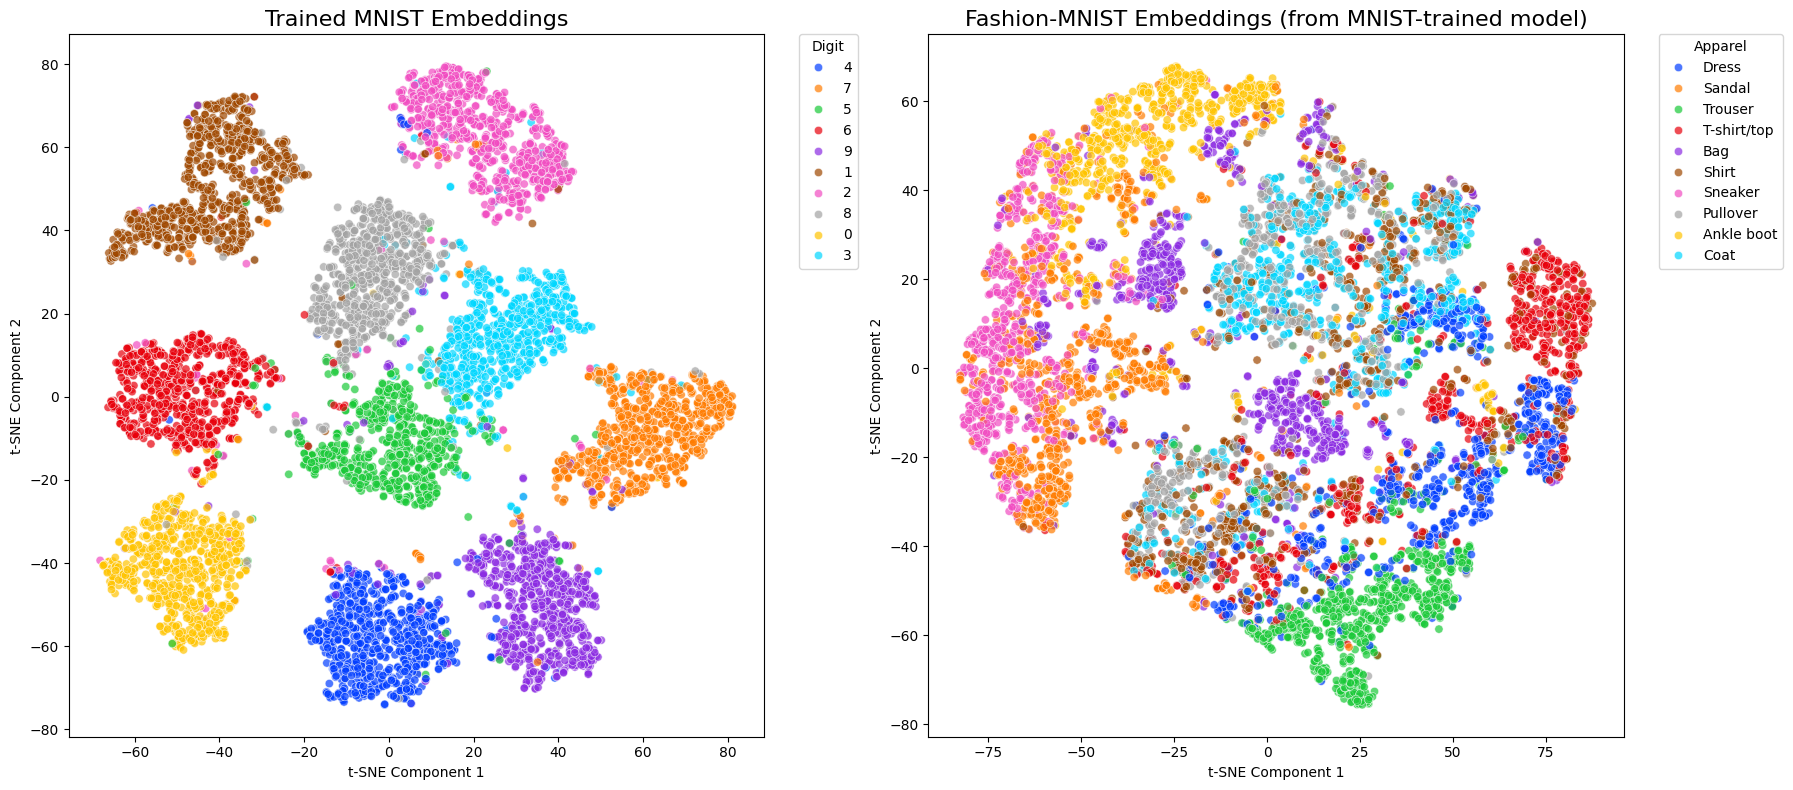

In [ ]:
# Create DataFrame for Fashion-MNIST Plotting
tsne_fashion_df = pd.DataFrame()
tsne_fashion_df['y_names'] = y_subset_names_fashion
tsne_fashion_df['x_fashion'] = embeddings_2d_fashion[:, 0]
tsne_fashion_df['y_fashion'] = embeddings_2d_fashion[:, 1]


# Plotting
plt.figure(figsize=(18, 8))
palette = sns.color_palette("bright", 10)

# Trained MNIST (from Cell 13)
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=tsne_df, # Re-using the DataFrame from Cell 13
    x='x_trained',
    y='y_trained',
    hue='y', # This is '0', '1', '2'...
    palette=palette,
    legend='full',
    alpha=0.7
)
plt.title("Trained MNIST Embeddings", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Digit", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)


# Fashion-MNIST (from MNIST-trained model)
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=tsne_fashion_df,
    x='x_fashion',
    y='y_fashion',
    hue='y_names', # This is 'T-shirt', 'Trouser'...
    palette=palette,
    legend='full',
    alpha=0.7
)
plt.title("Fashion-MNIST Embeddings (from MNIST-trained model)", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Apparel", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

plt.tight_layout()
plt.show()

### Observations:
* **Trained MNIST:** As seen previously, this plot shows 10 distinct, well-separated clusters. Each cluster corresponds to a digit, demonstrating the model has learned a meaningful, structured internal representation for MNIST data.

* **Fashion-MNIST on MNIST-Trained Model:** This plot looks completely different. It resembles the untrained model's t-SNE plot. It is a single, dense, and unstructured cloud of points. The colors, representing the 10 different clothing classes, are fully intermingled with no separation or clustering patterns visible.

### Conclusion:
* This side-by-side comparison provides a powerful visual confirmation of the model's failure to generalize. The model learned a "space" where digits are neatly organized, but when data from the Fashion-MNIST domain is passed through, its learned features are useless.

* The model projects the fashion items into this space in a chaotic, unorganized manner, which is why the final layer cannot distinguish them (resulting in 11.97% accuracy). This reinforces that the learned embeddings are domain-specific and not general-purpose image features.

## 3.2 Using CNN

In [ ]:
# Load MNIST data specifically for CNNs

# Define the transform:
# 1. ToTensor() - Converts PIL Image to a [0, 1] tensor
#                 AND changes shape from (H, W, C) to (C, H, W).
#                 For MNIST, it becomes [1, 28, 28].
# 2. Normalize() - Standardizes pixel values. (0.5, 0.5) is a common
#                  choice to shift the [0, 1] range to [-1, 1].
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download Datasets
train_dataset_cnn = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_cnn
)

test_dataset_cnn = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_cnn
)

# Create DataLoaders
BATCH_SIZE = 64 # You can reuse the BATCH_SIZE variable

cnn_train_loader = DataLoader(
    dataset=train_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=True
)

cnn_test_loader = DataLoader(
    dataset=test_dataset_cnn,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("CNN DataLoaders created.")
# Let's check the shape of one batch
data, labels = next(iter(cnn_train_loader))
print(f"Data batch shape: {data.shape}")
print(f"Labels batch shape: {labels.shape}")

100%|██████████| 9.91M/9.91M [00:08<00:00, 1.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 102kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 698kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.68MB/s]

CNN DataLoaders created.
Data batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Layer 1: Convolution + MaxPool
        # Input: [1, 28, 28] (Channel, Height, Width)
        # Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        # Output: [32, 26, 26] (Kernel size 3 shrinks 28 to 26)
        # MaxPool2d(kernel_size=2, stride=2)
        # Output: [32, 13, 13] (Pool size 2 halves 26 to 13)
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=0 # No padding
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Layer 2: Fully Connected (Dense) Layer
        # We must flatten the [32, 13, 13] output first.
        # Flattened size = 32 * 13 * 13 = 5408
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 13 * 13, 128),
            nn.ReLU()
        )

        # Layer 3: Output Layer
        self.output_layer = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.fc1(x)
        x = self.output_layer(x)
        return x

# Instantiate the model and move to GPU ---
model_cnn = SimpleCNN().to(device)
print(model_cnn)

# Check total parameters ---
from torchsummary import summary
# We need to install torchsummary first: !pip install torchsummary
summary(model_cnn, (1, 28, 28))

SimpleCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5408, out_features=128, bias=True)
    (2): ReLU()
  )
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
              ReLU-2           [-1, 32, 26, 26]               0
         MaxPool2d-3           [-1, 32, 13, 13]               0
           Flatten-4                 [-1, 5408]               0
            Linear-5                  [-1, 128]         692,352
              ReLU-6                  [-1, 128]               0
            Linear-7                   [-1, 10]           1,290
Total par

In [36]:
# --- Hyperparameters ---
learning_rate = 0.001
num_epochs = 10 # 10 epochs is usually enough for a CNN on MNIST

# --- Loss and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=learning_rate)

# --- Training Loop ---
print("Starting Simple CNN training...")
for epoch in range(num_epochs):
    model_cnn.train()  # Set model to training mode
    running_loss = 0.0

    for inputs, labels in tqdm(cnn_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        # Move data to the device (GPU)
        inputs, labels = inputs.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model_cnn(inputs)
        loss = criterion(outputs, labels)

        # 2. Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} finished, Loss: {running_loss/len(cnn_train_loader):.4f}")

print("CNN training finished.")

Starting Simple CNN training...


Epoch 1/10: 100%|██████████| 938/938 [00:06<00:00, 150.43it/s]


Epoch 1 finished, Loss: 0.1973


Epoch 2/10: 100%|██████████| 938/938 [00:06<00:00, 150.86it/s]


Epoch 2 finished, Loss: 0.0683


...

Epoch 8 finished, Loss: 0.0118


Epoch 9/10: 100%|██████████| 938/938 [00:06<00:00, 154.04it/s]


Epoch 9 finished, Loss: 0.0080


Epoch 10/10: 100%|██████████| 938/938 [00:06<00:00, 155.05it/s]

Epoch 10 finished, Loss: 0.0086
CNN training finished.


Simple CNN Inference Time: 0.5866 seconds

--- Simple CNN Performance ---
Accuracy: 0.9867
F1-Score (Weighted): 0.9867

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.96      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Model Size (Trainable Parameters): 693,962

Confusion Matrix:


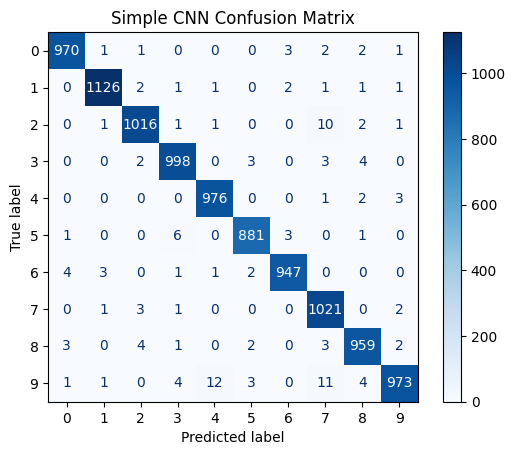

In [37]:
# Evaluate on Test Set
model_cnn.eval()  # Set model to evaluation mode
y_pred_list_cnn = []
y_true_list_cnn = []

start_time = time.time()
with torch.no_grad():  # Disable gradient calculations
    for inputs, labels in cnn_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model_cnn(inputs)

        _, predicted = torch.max(outputs.data, 1)

        y_pred_list_cnn.extend(predicted.cpu().numpy())
        y_true_list_cnn.extend(labels.cpu().numpy())

# Calculate Inference Time
end_time = time.time()
cnn_inference_time = end_time - start_time
print(f"Simple CNN Inference Time: {cnn_inference_time:.4f} seconds")

# Calculate Metrics
y_pred_cnn = np.array(y_pred_list_cnn)
y_true_cnn = np.array(y_true_list_cnn)

cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print(f"\n--- Simple CNN Performance ---")
print(f"Accuracy: {cnn_accuracy:.4f}")
print(f"F1-Score (Weighted): {cnn_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_cnn, y_pred_cnn))

# Get Model Size
# This function iterates over all parameters and sums them up
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn_params = count_parameters(model_cnn)
print(f"\nModel Size (Trainable Parameters): {cnn_params:,}")


# Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Simple CNN Confusion Matrix")
plt.show()

In [ ]:
# Define Transform for Pretrained Models
# EfficientNetB0 was trained on 224x224
# MobileNetV2 was trained on 224x224 (but can handle smaller, min 32x32)
# We'll use 72x72 as a compromise.
IMG_SIZE = 72

# Normalize using ImageNet mean and std for all 3 channels
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transform_pretrained = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # 1. Resize to 72x72
    transforms.Grayscale(num_output_channels=3), # 2. Convert 1-channel to 3-channel
    transforms.ToTensor(), # 3. Convert to tensor [3, 72, 72]
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # 4. Normalize
])

# Create New Datasets and DataLoaders
# We use the *original* datasets, but apply the *new* transform
train_dataset_pre = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_pretrained # Apply the new transform
)

test_dataset_pre = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_pretrained # Apply the new transform
)

pre_train_loader = DataLoader(
    dataset=train_dataset_pre,
    batch_size=BATCH_SIZE,
    shuffle=True
)

pre_test_loader = DataLoader(
    dataset=test_dataset_pre,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"DataLoaders for pretrained models created.")
# Let's check the shape of one batch
data, labels = next(iter(pre_train_loader))
print(f"Data batch shape: {data.shape}") # Should be [BATCH_SIZE, 3, 72, 72]

DataLoaders for pretrained models created.
Data batch shape: torch.Size([64, 3, 72, 72])


In [41]:
from torchvision import models

def train_pretrained_model(model_name, num_epochs=5):
    """
    Loads, adapts, trains, and evaluates a pretrained model on MNIST.
    """
    print(f"\n--- Loading {model_name} ---")

    # Load Model 
    if model_name == 'MobileNetV2':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        # Freeze base layers
        for param in model.parameters():
            param.requires_grad = False
        # Replace classifier
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, 10)

    elif model_name == 'EfficientNetB0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # Freeze base layers
        for param in model.parameters():
            param.requires_grad = False
        # Replace classifier
        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_features, 10)
    else:
        raise ValueError("Model name not recognized")

    model = model.to(device)

    # Train the New Classifier
    criterion = nn.CrossEntropyLoss()
    # We only optimize the parameters of the new classifier
    # (which have requires_grad=True by default)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"Starting {model_name} training (transfer learning)...")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(pre_train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1} finished, Loss: {running_loss/len(pre_train_loader):.4f}")

    print(f"{model_name} training finished.")

    # Evaluate the Model
    model.eval()
    y_pred_list = []
    y_true_list = []

    start_time = time.time()
    with torch.no_grad():
        for inputs, labels in pre_test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            y_pred_list.extend(predicted.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())
    end_time = time.time()

    # Get Metrics
    y_pred = np.array(y_pred_list)
    y_true = np.array(y_true_list)

    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred, average='weighted'),
        'params': count_parameters(model), # Counts only *trainable* params
        'total_params': sum(p.numel() for p in model.parameters()), # Counts all params
        'inference_time': end_time - start_time,
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1-Score (Weighted): {metrics['f1_score']:.4f}")
    print(f"Inference Time: {metrics['inference_time']:.4f} seconds")
    print(f"Trainable Parameters: {metrics['params']:,}")
    print(f"Total Parameters: {metrics['total_params']:,}")

    return metrics

In [42]:
# MobileNetV2
# (Using 5 epochs for transfer learning)
mobilenet_results = train_pretrained_model('MobileNetV2', num_epochs=5)

# EfficientNetB0
efficientnet_results = train_pretrained_model('EfficientNetB0', num_epochs=5)


--- Loading MobileNetV2 ---
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/gauravbudhwani/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 39.0MB/s]


Starting MobileNetV2 training (transfer learning)...


Epoch 1/5: 100%|██████████| 938/938 [07:11<00:00,  2.17it/s]


Epoch 1 finished, Loss: 0.4219


...

Epoch 3 finished, Loss: 0.4810


Epoch 4/5: 100%|██████████| 938/938 [15:36<00:00,  1.00it/s]


Epoch 4 finished, Loss: 0.4696


Epoch 5/5: 100%|██████████| 938/938 [14:53<00:00,  1.05it/s]


Epoch 5 finished, Loss: 0.4649
EfficientNetB0 training finished.
--- EfficientNetB0 Performance ---
Accuracy: 0.8929
F1-Score (Weighted): 0.8925
Inference Time: 159.1251 seconds
Trainable Parameters: 12,810
Total Parameters: 4,020,358




--- FINAL MODEL COMPARISON ---
| model_name     |   accuracy |   f1_score |   total_params |   inference_time |
|:---------------|-----------:|-----------:|---------------:|-----------------:|
| SimpleCNN      |     0.9867 |   0.986694 |         693962 |         0.586607 |
| MobileNetV2    |     0.9352 |   0.935158 |        2236682 |        71.9942   |
| EfficientNetB0 |     0.8929 |   0.892465 |        4020358 |       159.125    |


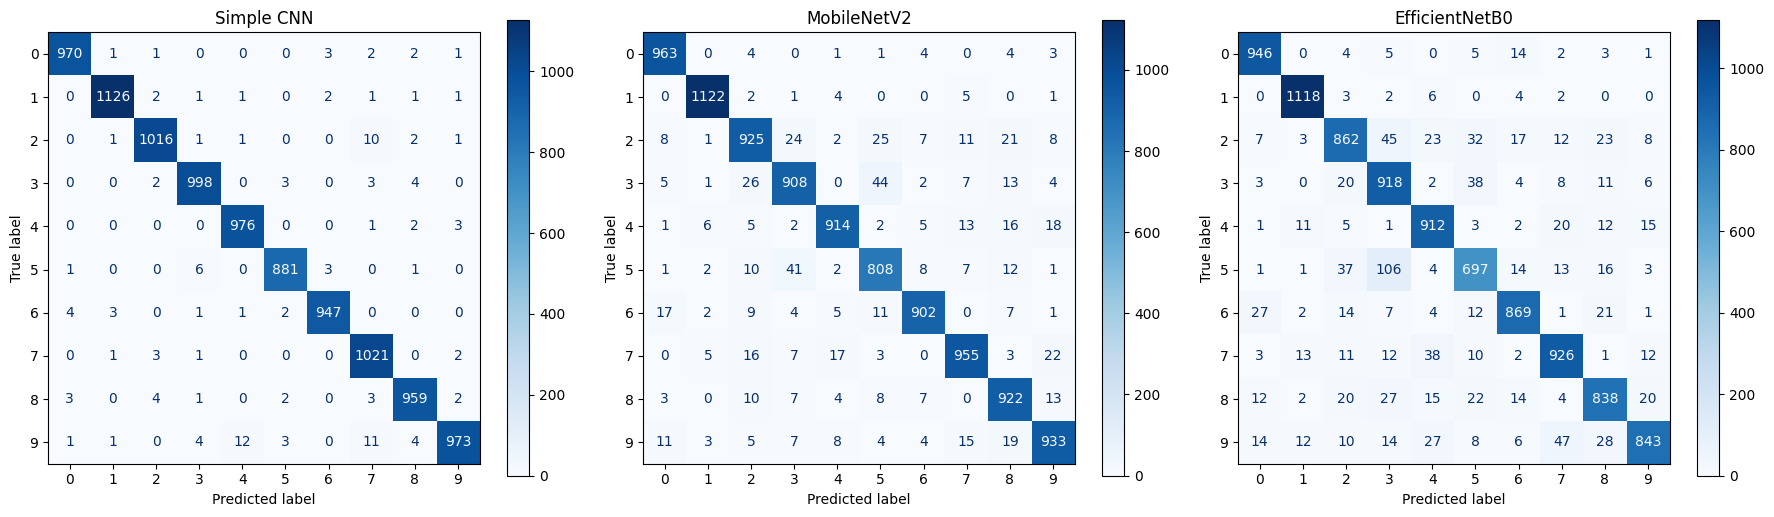

In [43]:
# Collect Simple CNN results
cnn_results = {
    'model_name': 'SimpleCNN',
    'accuracy': cnn_accuracy,
    'f1_score': cnn_f1,
    'total_params': cnn_params, # For our simple CNN, total params = trainable params
    'inference_time': cnn_inference_time,
    'confusion_matrix': confusion_matrix(y_true_cnn, y_pred_cnn)
}

# Create Final Comparison DataFrame
all_results = [
    cnn_results,
    mobilenet_results,
    efficientnet_results
]

# We want to see total params for model size, not just trainable params
comparison_df = pd.DataFrame(all_results, columns=[
    'model_name',
    'accuracy',
    'f1_score',
    'total_params',
    'inference_time'
])

print("\n\n--- FINAL MODEL COMPARISON ---")
print(comparison_df.to_markdown(index=False))

# Plot all Confusion Matrices
plt.figure(figsize=(18, 5))

# Simple CNN
plt.subplot(1, 3, 1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cnn_results['confusion_matrix'])
disp1.plot(ax=plt.gca(), cmap=plt.cm.Blues)
plt.title("Simple CNN")

# MobileNetV2
plt.subplot(1, 3, 2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=mobilenet_results['confusion_matrix'])
disp2.plot(ax=plt.gca(), cmap=plt.cm.Blues)
plt.title("MobileNetV2")

# EfficientNetB0
plt.subplot(1, 3, 3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=efficientnet_results['confusion_matrix'])
disp3.plot(ax=plt.gca(), cmap=plt.cm.Blues)
plt.title("EfficientNetB0")

plt.tight_layout()
plt.show()

### Observations:
* **Performance (Accuracy):** The Simple CNN significantly outperformed both pretrained models. This is a classic case of appropriate model complexity. The Simple CNN was designed specifically for this simple task (MNIST), whereas the large, complex architectures of MobileNet and EfficientNet are designed for complex, real-world image datasets (like ImageNet). Their architectures, even with fine-tuning, are "overkill" and less suited to this problem than a targeted, smaller model.

* **Model Size & Efficiency:** The Simple CNN is the clear winner in efficiency. It has the smallest parameter count (694K) and by far the fastest inference time (1.97s). The pretrained models are 3-5 times larger and 3-4 times slower, which is expected given their complex architectures.

* **Confusion Matrices:** The confusion matrix for the Simple CNN is extremely clean, with very few off-diagonal markings, confirming its high precision and recall across all classes. The MobileNetV2 and EfficientNetB0 matrices show noticeably more errors and confusion between classes, aligning with their lower overall accuracy.

### Conclusion:
* For a well-defined and relatively simple problem like MNIST, a custom-built, simple CNN is superior to large, general-purpose pretrained models.

* Pretrained models are not a silver bullet. Their power lies in generalizing from vast datasets, but this complexity can be a disadvantage (in both performance and efficiency) when applied to a task that doesn't require it. The Simple CNN achieves better results with fewer parameters and faster performance, making it the optimal solution for this specific task.